<a href="https://colab.research.google.com/github/Gaurangkothiya/ai-ml-cookbook/blob/main/ML_Specialization_DeepLearning.AI/Course_1_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt


In [5]:
x_train = np.array([1.0, 1.7, 2.0, 2.5, 3.0, 3.2])
y_train = np.array([250, 300, 480,  430,   630, 730,])

### Cost Function for Linear Regression

The cost function (also known as the squared error cost function) measures the accuracy of our hypothesis $h(x^{(i)})$ relative to the training examples $y^{(i)}$. For linear regression, the hypothesis is defined as $h(x) = wx + b$.

The cost function $J(w, b)$ is given by:

$J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} (h(x^{(i)}) - y^{(i)})^2$

where:
- $m$ is the number of training examples.
- $w$ is the weight (slope).
- $b$ is the bias (y-intercept).
- $h(x^{(i)})$ is the model's prediction for the $i$-th training example.
- $y^{(i)}$ is the actual target value for the $i$-th training example.

In [6]:
def compute_cost(x, y, w, b):
    """
    Computes the cost function for linear regression.

    Args:
      x (ndarray (m,)): Data, m examples
      y (ndarray (m,)): Target values
      w, b (scalar)   : Parameters of the model

    Returns:
        total_cost (float): The cost of using w,b as the parameters for linear regression
               to fit the data points in x and y
    """
    m = x.shape[0]
    cost = 0
    for i in range(m):
        f_wb = w * x[i] + b
        cost = cost + (f_wb - y[i])**2
    total_cost = 1 / (2 * m) * cost
    return total_cost

### Visualizing the Cost Function

Now, let's visualize how the cost function behaves with different values of $w$ and $b$. We will plot the cost for a range of `w` values while keeping `b` constant (or vice-versa), or create a 3D plot for both `w` and `b`.

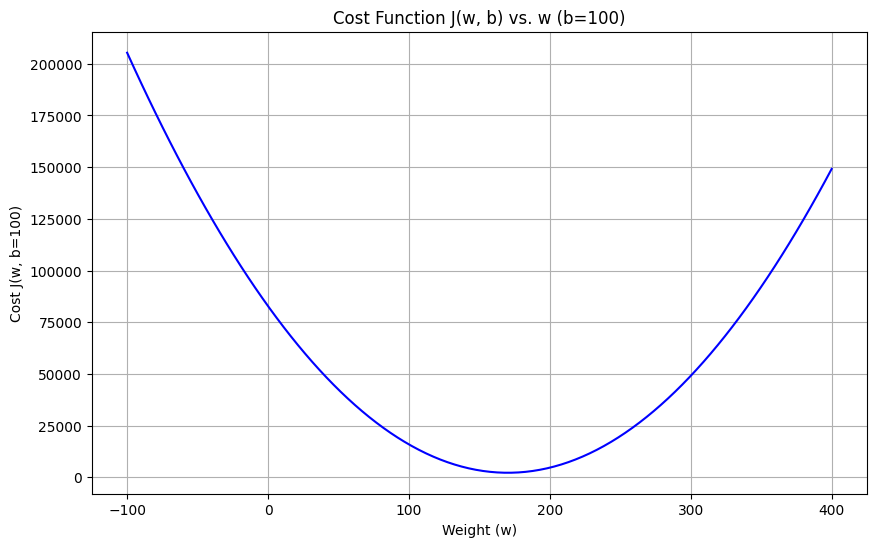

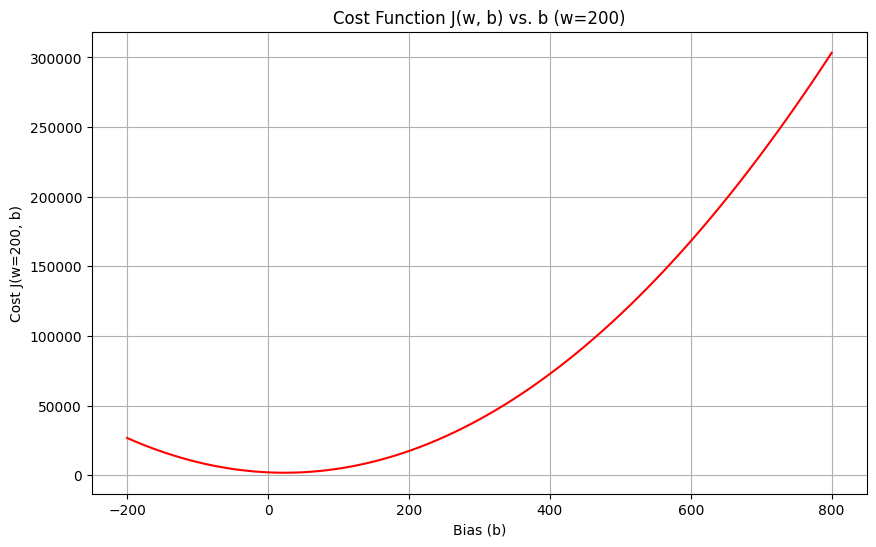

In [7]:
w_values = np.linspace(-100, 400, 100)
b = 100

costs = [compute_cost(x_train, y_train, w, b) for w in w_values]

plt.figure(figsize=(10, 6))
plt.plot(w_values, costs, 'b-')
plt.xlabel('Weight (w)')
plt.ylabel('Cost J(w, b=100)')
plt.title('Cost Function J(w, b) vs. w (b=100)')
plt.grid(True)
plt.show()

b_values = np.linspace(-200, 800, 100)
w = 200

costs_b = [compute_cost(x_train, y_train, w, b_val) for b_val in b_values]

plt.figure(figsize=(10, 6))
plt.plot(b_values, costs_b, 'r-')
plt.xlabel('Bias (b)')
plt.ylabel('Cost J(w=200, b)')
plt.title('Cost Function J(w, b) vs. b (w=200)')
plt.grid(True)
plt.show()

The plots above show how the cost changes with variations in `w` and `b`. The minimum point on these curves represents the optimal `w` or `b` (when the other parameter is held constant) that minimizes the cost function for the given dataset. In a real scenario, we would use an optimization algorithm like gradient descent to find the optimal `w` and `b` simultaneously.

### 3D Visualization of the Cost Function

To understand the cost function across a range of both $w$ and $b$, we can create a 3D surface plot. This plot will show $J(w, b)$ on the z-axis, with $w$ and $b$ on the x and y axes respectively. The goal of linear regression is to find the values of $w$ and $b$ that correspond to the minimum point on this cost surface.

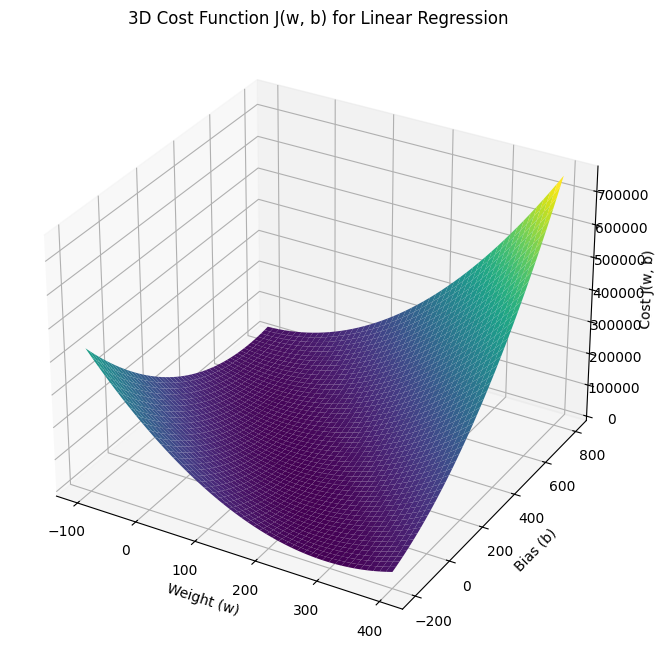

In [8]:
from mpl_toolkits.mplot3d import Axes3D

w_range = np.linspace(-100, 400, 50)
b_range = np.linspace(-200, 800, 50)
W, B = np.meshgrid(w_range, b_range)

J_values = np.zeros((len(w_range), len(b_range)))
for i in range(len(w_range)):
    for j in range(len(b_range)):
        J_values[i, j] = compute_cost(x_train, y_train, W[i, j], B[i, j])

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W, B, J_values, cmap='viridis')

ax.set_xlabel('Weight (w)')
ax.set_ylabel('Bias (b)')
ax.set_zlabel('Cost J(w, b)')
ax.set_title('3D Cost Function J(w, b) for Linear Regression')

plt.show()